## Q5 Findings: Publisher Dominance by Region

**Nintendo is #1 in every region — but the scale of dominance varies dramatically:**

| Region    | Nintendo Sales    | #2 Publisher              | Nintendo Lead |
|---        |---                |---                        |---            |
| NA        | $816.87M          | EA ($595M)                | 1.4×          |
| EU        | $418.74M          | EA ($371M)                | 1.1×          |
| **JP**    | **$455.42M**      | **Namco Bandai ($127M)**  | **3.6×**      |
| Other     | $95.33M           | (EA leads at $130M)       | Nintendo #2   |

**The Japanese market has a structurally different composition:**
- 8 of 10 top publishers in Japan are Japanese companies (Nintendo, Namco Bandai,
  Konami, Sony, Capcom, Sega, Square Enix, SquareSoft, Enix, Tecmo Koei)
- Compare to NA/EU where the top 3 (Nintendo, EA, Activision) are identical 
  and 8 of 10 publishers overlap between the two regions
- "Other" region publisher ranking closely mirrors NA — a smaller version 
  of the same Western/global publisher landscape

**Publisher market focus is real:**
Some publishers are essentially region-specific:
- EA in Japan: $14M (2.4% of their NA sales) — Western-focused
- Namco Bandai in Japan: $127M vs $69M in NA — Japan-first
- Enix Corporation: $32M JP vs $0.76M NA — Japan-only

**Analytical concept:** Publisher strength is region-focused rather than uniformly 
global. Publishers position through different market strategies — global 
(Nintendo, Sony), Western-focused (EA, Activision, Ubisoft), or Japan-focused 
(Namco Bandai, Square Enix, Konami, Capcom). Assumption of worldwide symmetry 
would systematically misestimate publisher strength in any given market.

**Note on chart interpretation:** X-axes are region-specific, so bar lengths 
cannot be compared directly across panels. Each panel shows within-region 
ranking; magnitude across regions is available in the underlying data.

**Follow-up questions this raises:**
- Are these regional patterns stable over time or shifting? (Would need Q3's 
  time-series pattern combined with Q5's publisher-region view)
- How much of Nintendo's dominance in Japan depends on hardware exclusivity 
  vs Nintendo's software franchises?
- Do specific genres drive specific publisher dominance? (Q4 + Q5 combined 
  view would reveal this)

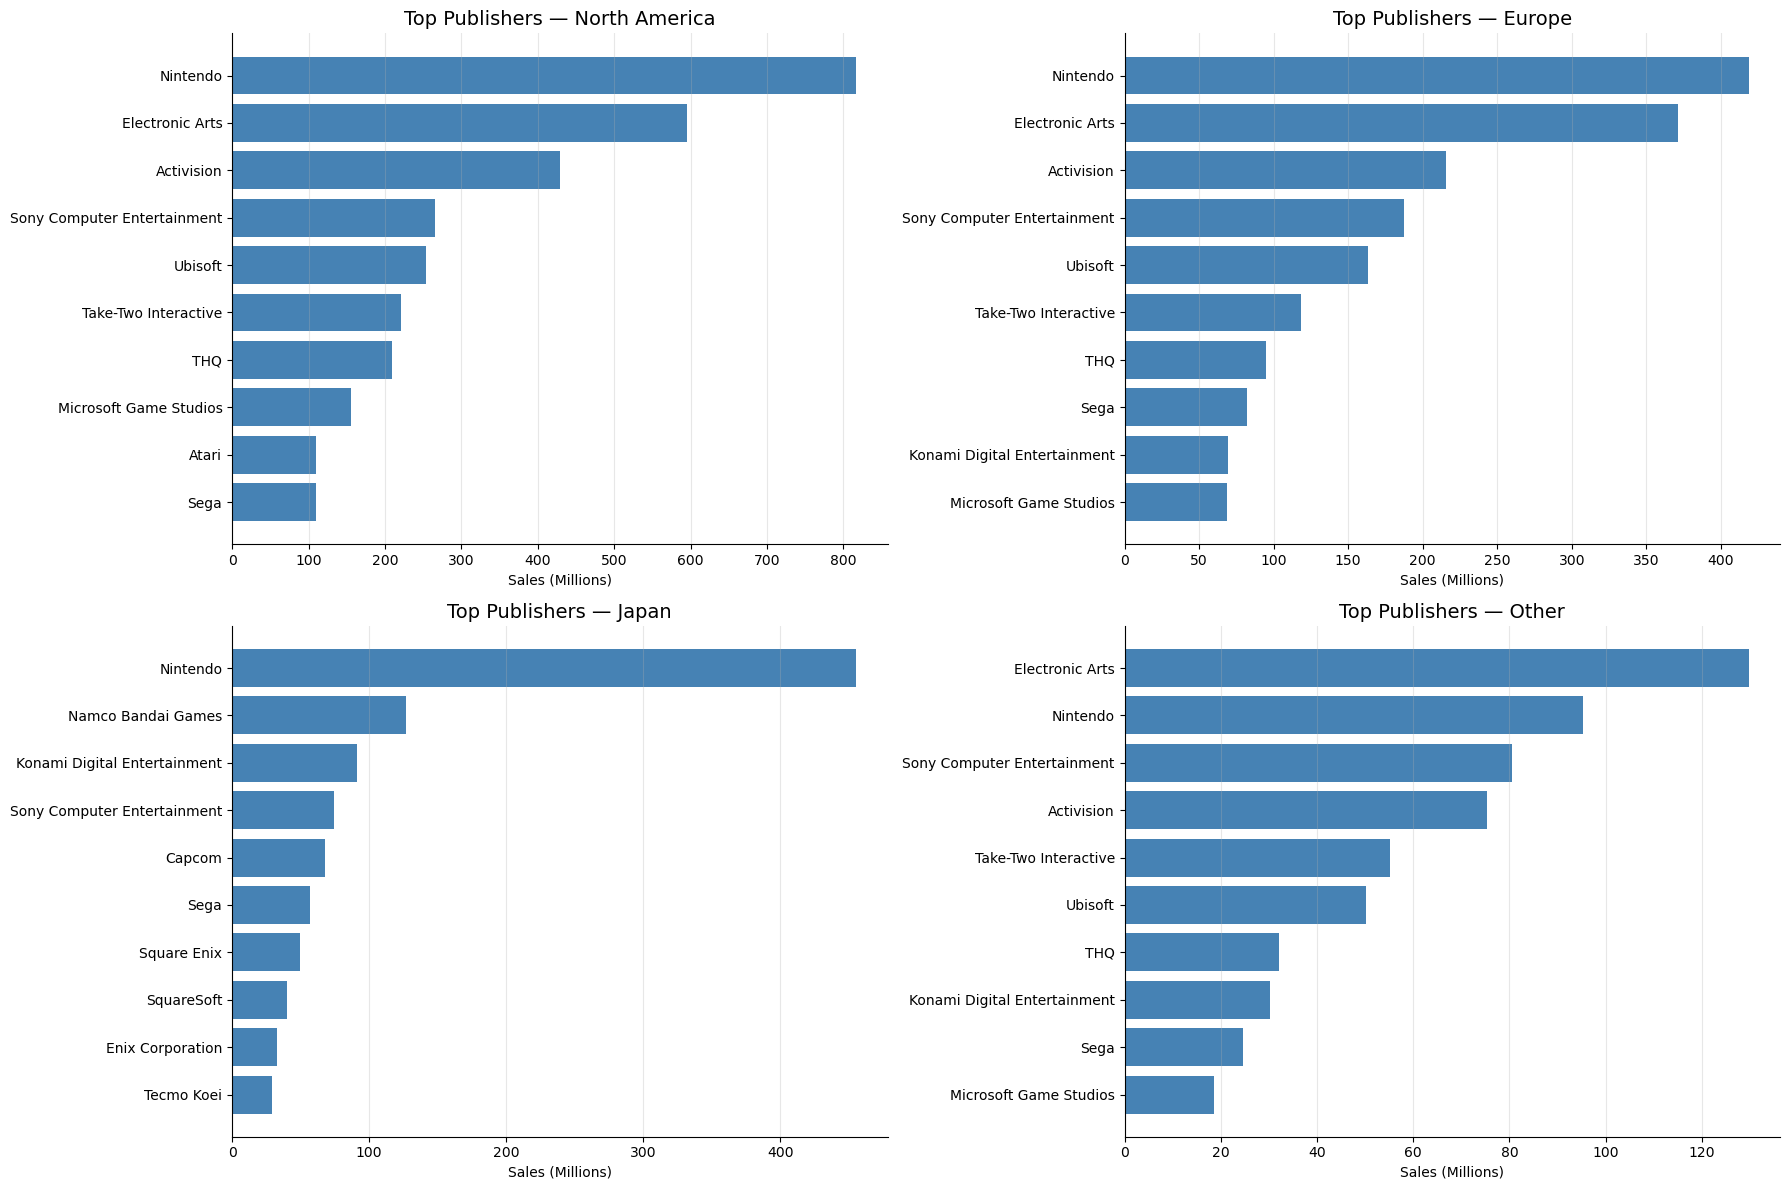

In [ ]:
# Step 3 - Visualise the Findings for Top Publishers by Region.

import matplotlib.pyplot as plt

# 1. Prepare top-10 tables (already computed earlier)
# top_na_publishers
# top_eu_publishers
# top_jp_publishers
# top_other_publishers

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

region_tables = [
    ("North America", "NA_Sales", top_na_publishers, axes[0, 0]),
    ("Europe",        "EU_Sales", top_eu_publishers, axes[0, 1]),
    ("Japan",         "JP_Sales", top_jp_publishers, axes[1, 0]),
    ("Other",         "Other_Sales", top_other_publishers, axes[1, 1])
]

# 2. Plot each region's top 10 publishers
for region_name, sales_col, table, ax in region_tables:
    
    table_sorted = table.sort_values(sales_col, ascending=True)

    ax.barh(
        table_sorted.index,
        table_sorted[sales_col],
        color="steelblue"
    )

    ax.set_title(f"Top Publishers — {region_name}", fontsize=14)
    ax.set_xlabel("Sales (Millions)")
    ax.grid(axis="x", alpha=0.3)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("outputs/q5_publishers_by_region.png", dpi=300, bbox_inches="tight")
plt.show()


In [5]:
# Step 2 - Compute Top Publishers by Region.

# 1. Total regional sales per publisher
publisher_region = (
    df.groupby("Publisher")[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]]
      .sum()
)

# 2. Top 10 publishers per region (separate sorts)
top_na_publishers = (
    publisher_region.sort_values("NA_Sales", ascending=False)
                    .head(10)
)

top_eu_publishers = (
    publisher_region.sort_values("EU_Sales", ascending=False)
                    .head(10)
)

top_jp_publishers = (
    publisher_region.sort_values("JP_Sales", ascending=False)
                    .head(10)
)

top_other_publishers = (
    publisher_region.sort_values("Other_Sales", ascending=False)
                    .head(10)
)

top_na_publishers, top_eu_publishers, top_jp_publishers, top_other_publishers


(                             NA_Sales  EU_Sales  JP_Sales  Other_Sales
 Publisher                                                             
 Nintendo                       816.87    418.74    455.42        95.33
 Electronic Arts                595.07    371.27     14.04       129.77
 Activision                     429.70    215.53      6.54        75.34
 Sony Computer Entertainment    265.22    187.72     74.10        80.45
 Ubisoft                        253.43    163.32      7.50        50.26
 Take-Two Interactive           220.49    118.14      5.83        55.24
 THQ                            208.77     94.73      5.01        32.14
 Microsoft Game Studios         155.35     68.61      3.26        18.56
 Atari                          110.04     27.12     10.71         9.01
 Sega                           109.40     82.00     57.03        24.52,
                               NA_Sales  EU_Sales  JP_Sales  Other_Sales
 Publisher                                                    

In [1]:
# Step 1 - Load & Inspect Dataset.

import pandas as pd
from pathlib import Path

SCRIPT_DIR = Path().resolve()
df = pd.read_csv(SCRIPT_DIR / "data" / "vgsales.csv")
df.columns = df.columns.str.strip()

# Standard inspection
df.shape
df.columns.tolist()
df.dtypes
df.head()
df["Publisher"].nunique()
df["Publisher"].value_counts().head(10)
df["Year"].min(), df["Year"].max()
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64